# Amazon 销售数据分析与预测模型

---

## 目录

1. [业务理解](#1-业务理解)
2. [数据理解](#2-数据理解)
3. [数据清洗与特征工程](#3-数据清洗与特征工程)
4. [探索性数据分析 (EDA)](#4-探索性数据分析)
5. [退货预测模型](#5-退货预测模型)
6. [销量预测模型](#6-销量预测模型)
7. [商业洞察与建议](#7-商业洞察与建议)

> **分析框架**: CRISP-DM (Cross-Industry Standard Process for Data Mining)

> **数据集**: Amazon 2023年 Q1-Q4 销售订单数据，12,000 条记录

## 1. 业务理解

### 业务背景
作为亚马逊运营团队，我们需要通过数据驱动决策，核心关注以下问题：

| 业务问题 | 分析目标 |
|---------|---------|
| 哪些订单容易退货？ | 构建退货预测模型，提前识别高风险订单 |
| 未来销量趋势如何？ | 时间序列预测，辅助备货计划 |
| 哪些品类/产品贡献最大？ | 营收结构分析 |
| 不同地区的表现差异？ | 地域维度下钻 |

### 分析假设 (Hypothesis)
- H1: 低价产品退货率更高（冲动消费）
- H2: Q4 旺季销量显著高于其他季度
- H3: 不同品类退货率存在显著差异
- H4: 订单金额与退货概率负相关

## 2. 数据理解

### 2.1 导入库与数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# 中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
sns.set_palette('Set2')

# 加载数据
df = pd.read_csv('data/amazon_sales_2023.csv', encoding='utf-8-sig')
df['order_date'] = pd.to_datetime(df['order_date'])
print(f'数据维度: {df.shape}')
print(f'时间范围: {df["order_date"].min()} ~ {df["order_date"].max()}')
df.head()

数据维度: (12000, 12)
时间范围: 2023-01-01 00:47:00 ~ 2023-12-28 22:32:00


,order_id,order_date,product_name,category,unit_price,quantity,revenue,cost,profit,region,country,is_returned
0,AMZ-2023-000001,2023-12-11 07:20:00,机械键盘,电子产品,115.69,1,115.69,60,55.69,欧洲,UK,0
1,AMZ-2023-000002,2023-09-24 02:21:00,可折叠宠物笼,宠物用品,84.26,1,84.26,35,49.26,欧洲,DE,0
2,AMZ-2023-000003,2023-03-12 21:43:00,便携式充电宝,电子产品,79.59,1,79.59,35,44.59,亚太,SG,0
3,AMZ-2023-000004,2023-06-15 18:43:00,人体工学腕托,办公用品,25.69,1,25.69,9,16.69,亚太,SG,0
4,AMZ-2023-000005,2023-03-07 17:03:00,跑步腰包,运动户外,18.34,2,36.68,12,24.68,欧洲,IT,0


### 2.2 数据结构与类型

In [2]:
# 数据类型与缺失值检查
info_df = pd.DataFrame({
    '数据类型': df.dtypes,
    '缺失值': df.isnull().sum(),
    '缺失率(%)': (df.isnull().sum() / len(df) * 100).round(2),
    '唯一值数量': df.nunique()
})
info_df

,数据类型,缺失值,缺失率(%),唯一值数量
order_id,str,0,0.0,12000
order_date,datetime64[us],0,0.0,11836
product_name,str,0,0.0,28
category,str,0,0.0,5
unit_price,float64,0,0.0,6043
quantity,int64,0,0.0,3
revenue,float64,0,0.0,6615
cost,int64,0,0.0,40
profit,float64,0,0.0,5045
region,str,0,0.0,4


### 2.3 描述性统计

对数值型变量进行 **集中趋势** (均值、中位数) 和 **离散程度** (标准差、四分位数) 分析。

In [3]:
# 数值型变量描述性统计
num_cols = ['unit_price', 'quantity', 'revenue', 'cost', 'profit']
desc = df[num_cols].describe().T
desc['变异系数(CV)'] = (desc['std'] / desc['mean']).round(3)
desc['偏度'] = df[num_cols].skew().round(3)
desc['峰度'] = df[num_cols].kurtosis().round(3)
desc

,count,mean,std,min,25%,50%,75%,max,变异系数(CV),偏度,峰度
unit_price,12000.0,46.540276,38.313759,10.22,22.8475,35.265,52.1350,228.31,0.823,2.409,6.569
quantity,12000.0,1.173250,0.447494,1.00,1.0000,1.000,1.0000,3.00,0.381,2.623,6.293
revenue,12000.0,54.837289,53.822441,10.22,25.1100,39.245,62.5125,665.41,0.981,3.740,22.385
cost,12000.0,23.408167,24.830575,4.00,10.0000,18.000,28.0000,267.00,1.061,3.584,20.552
profit,12000.0,31.429122,29.440348,6.22,15.2475,22.660,35.1925,398.41,0.937,3.881,24.291


> **知识点**: 变异系数 (CV) = 标准差/均值，用于比较不同量纲变量的离散程度。偏度 > 0 右偏（长尾在右），峰度 > 3 厚尾分布。

## 3. 数据清洗与特征工程

In [4]:
# 3.1 时间特征提取
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter
df['day_of_week'] = df['order_date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['week_of_year'] = df['order_date'].dt.isocalendar().week.astype(int)

# 3.2 业务特征
df['profit_margin'] = df['profit'] / df['revenue']
df['price_level'] = pd.cut(df['unit_price'], bins=[0, 20, 50, 100, 500],
                           labels=['低价(<$20)', '中低价($20-50)', '中高价($50-100)', '高价(>$100)'])

# 3.3 类别编码 (用于建模)
le_cat = LabelEncoder()
le_region = LabelEncoder()
le_price = LabelEncoder()
df['category_encoded'] = le_cat.fit_transform(df['category'])
df['region_encoded'] = le_region.fit_transform(df['region'])
df['price_level_encoded'] = le_price.fit_transform(df['price_level'])

# 3.4 异常值检测 (IQR方法)
Q1, Q3 = df['revenue'].quantile(0.25), df['revenue'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['revenue'] < Q1 - 1.5*IQR) | (df['revenue'] > Q3 + 1.5*IQR)]
print(f'营收异常值(IQR方法)数量: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')
print(f'数据清洗后样本量: {len(df)}')
df[['month', 'quarter', 'day_of_week', 'is_weekend', 'profit_margin', 'price_level']].head()

营收异常值(IQR方法)数量: 1062 (8.8%)
数据清洗后样本量: 12000


,month,quarter,day_of_week,is_weekend,profit_margin,price_level
0,12,4,0,0,0.481373,高价(>$100)
1,9,3,6,1,0.584619,中高价($50-100)
2,3,1,6,1,0.560246,中高价($50-100)
3,6,2,3,0,0.649669,中低价($20-50)
4,3,1,1,0,0.672846,低价(<$20)


## 4. 探索性数据分析 (EDA)

### 4.1 营收分布分析

Mann-Whitney U 检验 p-value: 0.727348
-> 无显著差异 (alpha=0.05)


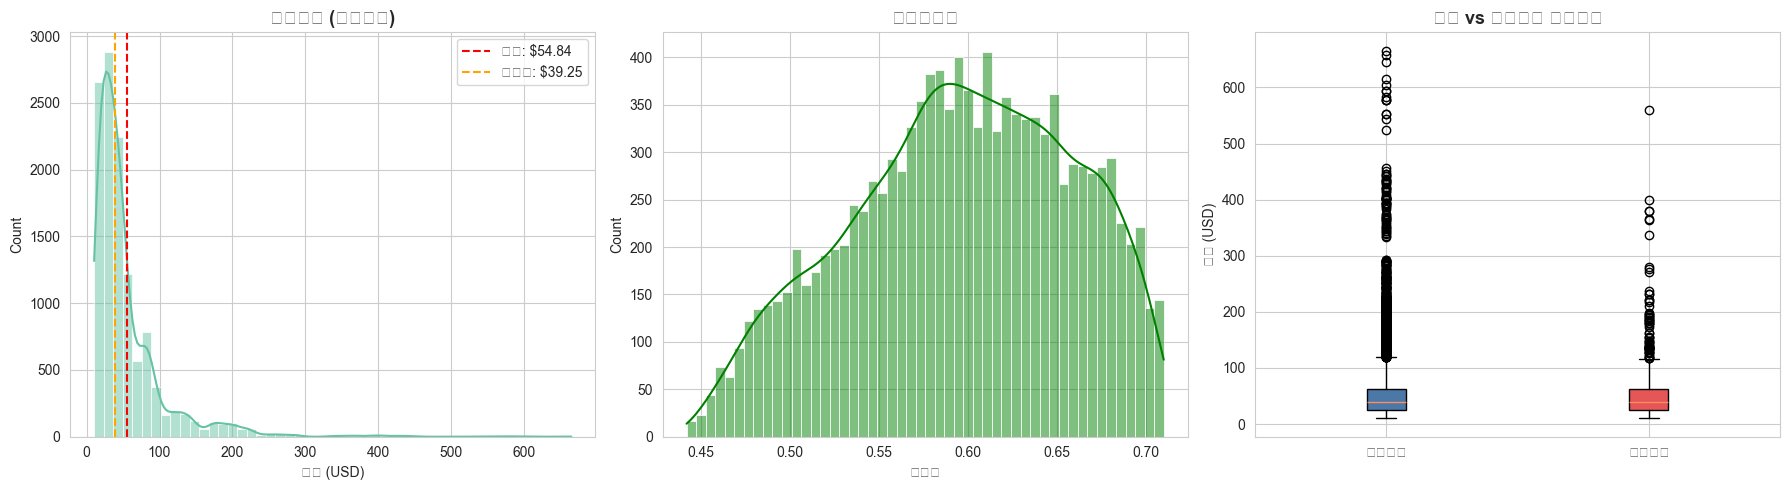

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 营收分布直方图 + KDE
ax = axes[0]
sns.histplot(df['revenue'], kde=True, bins=50, ax=ax, edgecolor='white')
ax.axvline(df['revenue'].mean(), color='red', linestyle='--', label=f'均值: ${df["revenue"].mean():.2f}')
ax.axvline(df['revenue'].median(), color='orange', linestyle='--', label=f'中位数: ${df["revenue"].median():.2f}')
ax.set_title('营收分布 (右偏分布)', fontsize=13, fontweight='bold')
ax.set_xlabel('营收 (USD)')
ax.legend()

# 利润率分布
ax = axes[1]
sns.histplot(df['profit_margin'], kde=True, bins=50, ax=ax, color='green', edgecolor='white')
ax.set_title('利润率分布', fontsize=13, fontweight='bold')
ax.set_xlabel('利润率')

# 退货 vs 正常 营收对比箱线图
ax = axes[2]
plot_data = [df[df['is_returned']==0]['revenue'], df[df['is_returned']==1]['revenue']]
bp = ax.boxplot(plot_data, labels=['正常订单', '退货订单'], patch_artist=True)
bp['boxes'][0].set_facecolor('#4C78A8'); bp['boxes'][1].set_facecolor('#E45756')
ax.set_title('退货 vs 正常订单 营收对比', fontsize=13, fontweight='bold')
ax.set_ylabel('营收 (USD)')

# Mann-Whitney U 检验
returned = df[df['is_returned']==1]['revenue']
normal = df[df['is_returned']==0]['revenue']
stat, p_mw = stats.mannwhitneyu(returned, normal, alternative='two-sided')
print(f'Mann-Whitney U 检验 p-value: {p_mw:.6f}')
print(f'-> {"退货订单营收显著低于正常订单" if p_mw < 0.05 else "无显著差异"} (alpha=0.05)')

plt.tight_layout()
plt.savefig('output_revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

> **知识点**: 营收呈右偏分布 (均值 > 中位数)。Mann-Whitney U 是非参数检验，不假设正态分布，用于比较两组独立样本的位置差异。

### 4.2 类别维度分析 — 假设检验 H3

卡方检验 (类别 vs 退货): chi2=0.45, p-value=0.978383
-> 无显著差异 (alpha=0.05)


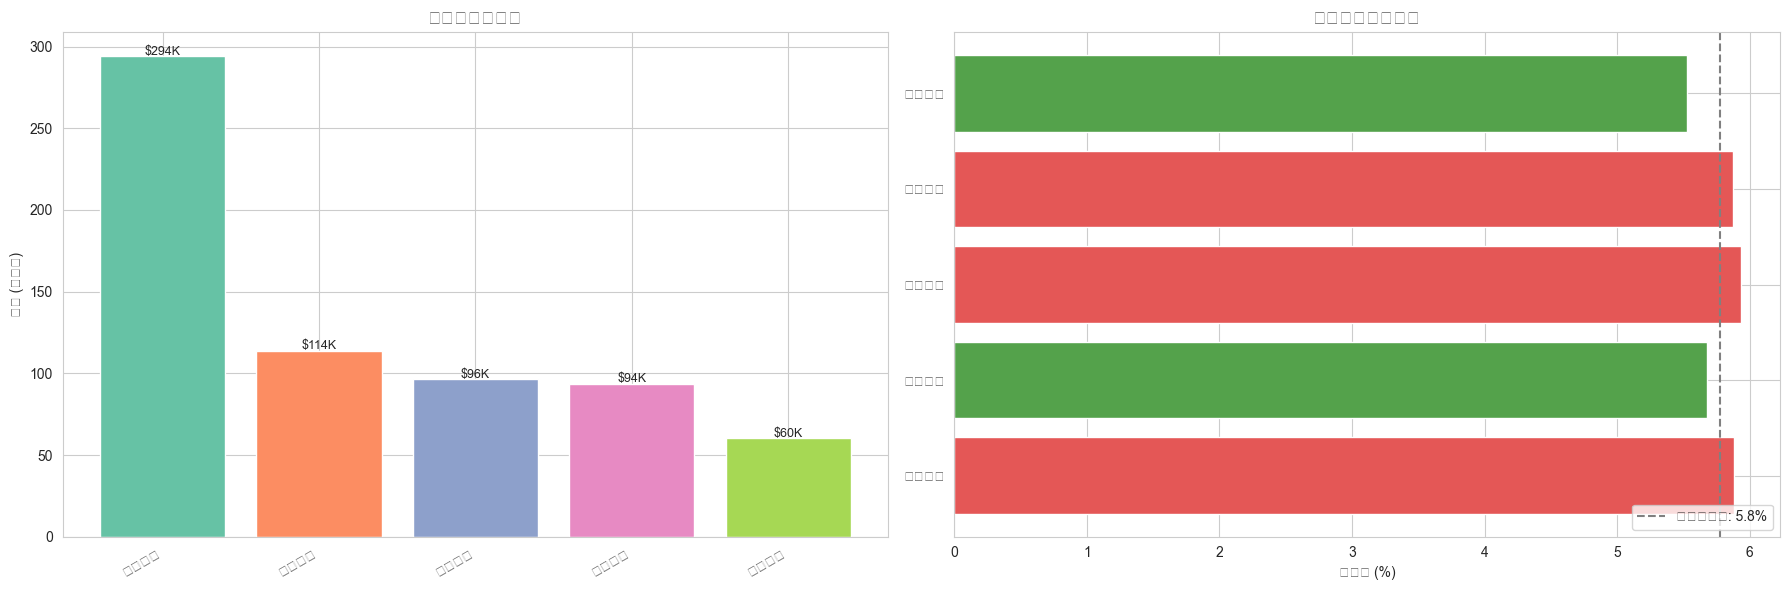

In [6]:
# 各类别营收 & 退货率
cat_stats = df.groupby('category').agg(
    revenue=('revenue', 'sum'),
    orders=('order_id', 'count'),
    return_rate=('is_returned', 'mean'),
    avg_price=('unit_price', 'mean')
).sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
bars = ax.bar(range(len(cat_stats)), cat_stats['revenue']/1000, color=sns.color_palette('Set2', len(cat_stats)))
ax.set_xticks(range(len(cat_stats)))
ax.set_xticklabels(cat_stats.index, rotation=30, ha='right')
ax.set_ylabel('营收 (千美元)')
ax.set_title('各类别营收贡献', fontsize=13, fontweight='bold')
for bar, val in zip(bars, cat_stats['revenue']/1000):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'${val:.0f}K', ha='center', fontsize=9)

ax = axes[1]
avg_return = cat_stats['return_rate'].mean()
colors = ['#E45756' if r > avg_return else '#54A24B' for r in cat_stats['return_rate']]
ax.barh(range(len(cat_stats)), cat_stats['return_rate']*100, color=colors)
ax.set_yticks(range(len(cat_stats)))
ax.set_yticklabels(cat_stats.index)
ax.set_xlabel('退货率 (%)')
ax.axvline(avg_return*100, color='gray', linestyle='--', label=f'平均退货率: {avg_return*100:.1f}%')
ax.set_title('各类别退货率对比', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')

# 卡方检验
contingency = pd.crosstab(df['category'], df['is_returned'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f'卡方检验 (类别 vs 退货): chi2={chi2:.2f}, p-value={p_chi:.6f}')
print(f'-> {"不同类别退货率存在显著差异" if p_chi < 0.05 else "无显著差异"} (alpha=0.05)')

plt.tight_layout()
plt.savefig('output_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

> **知识点**: 卡方检验 (Chi-Square Test) 用于检验两个分类变量是否独立。H0: 类别与退货相互独立。若 p < 0.05，拒绝 H0，说明不同类别退货率有显著差异。

### 4.3 时间维度分析 — 假设检验 H2

单因素 ANOVA (季度 vs 营收): F=2.06, p-value=0.103880
-> 无显著差异 (alpha=0.05)


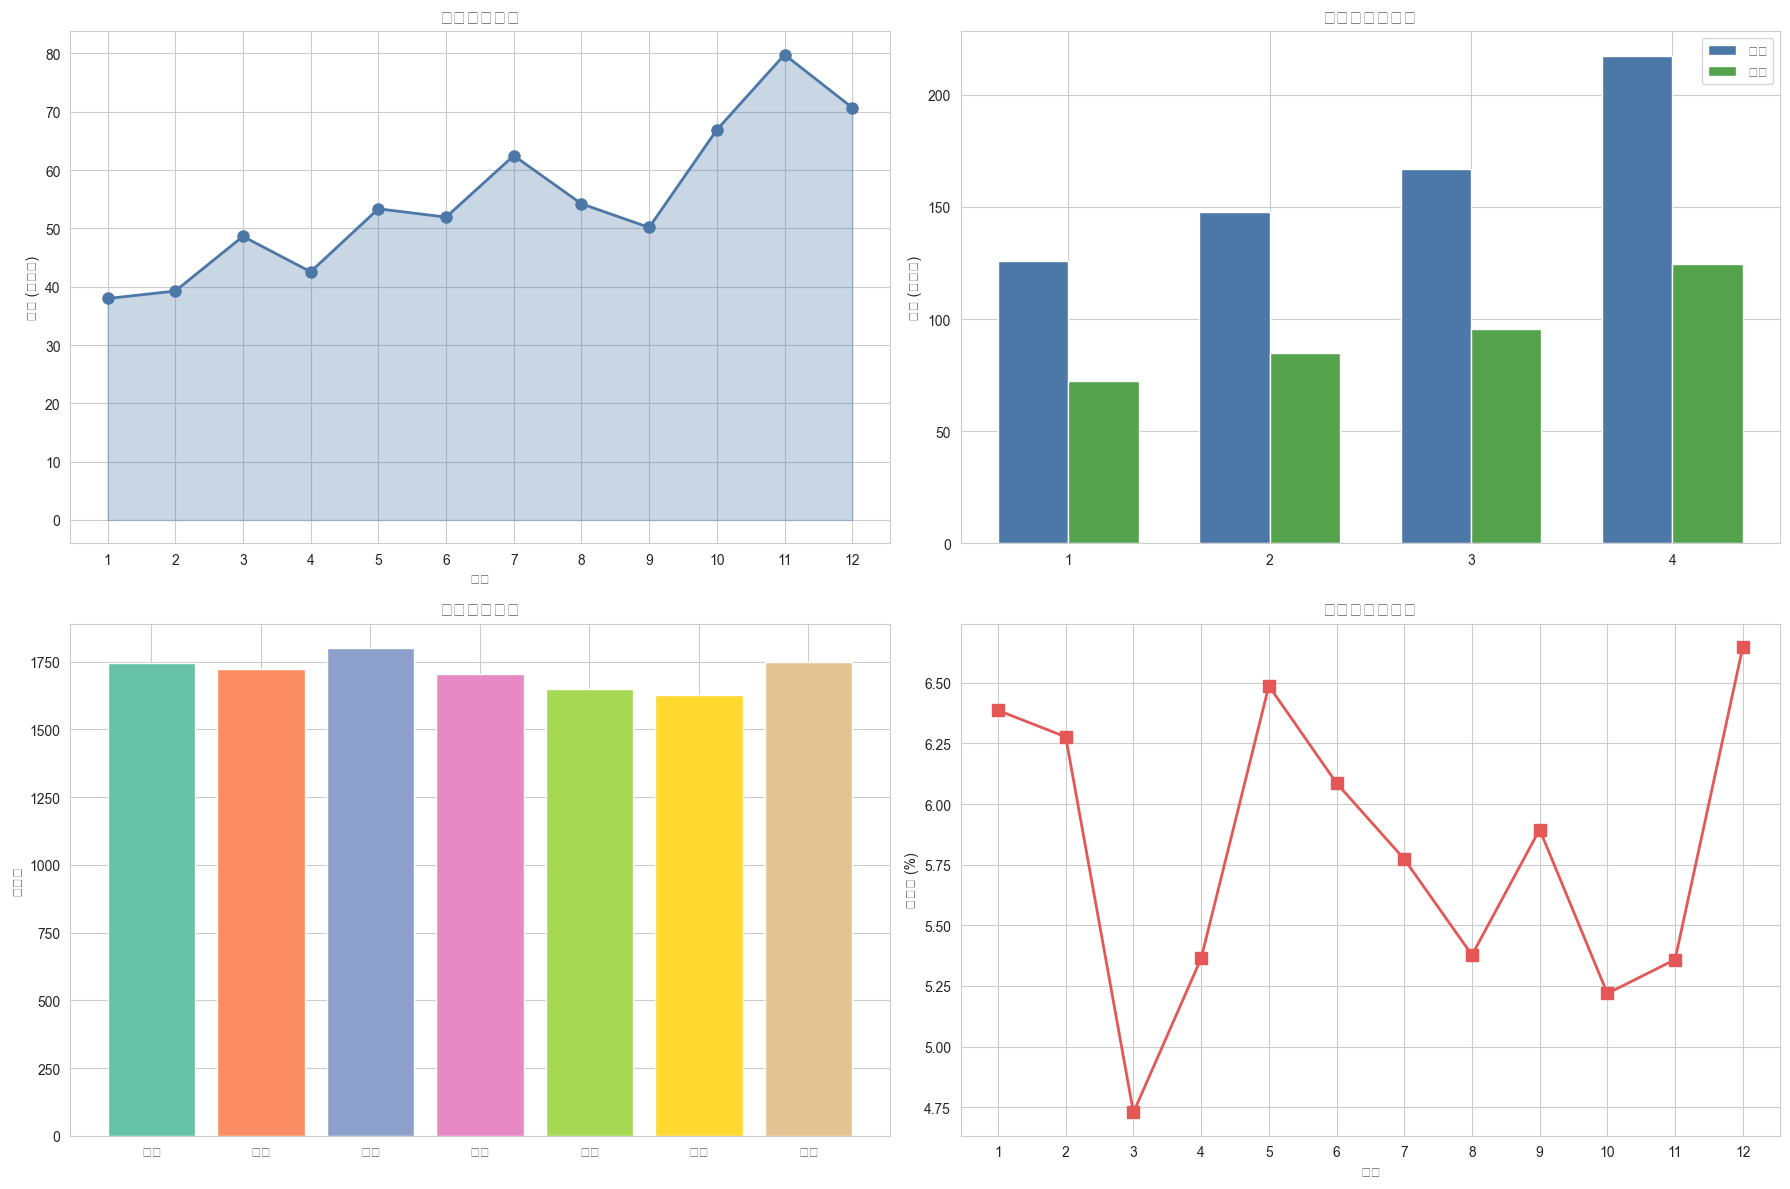

In [7]:
# 月度趋势
monthly = df.groupby('month').agg(
    revenue=('revenue', 'sum'), orders=('order_id', 'count'),
    return_rate=('is_returned', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 月度营收
ax = axes[0, 0]
ax.fill_between(monthly['month'], monthly['revenue']/1000, alpha=0.3, color='#4C78A8')
ax.plot(monthly['month'], monthly['revenue']/1000, marker='o', linewidth=2, color='#4C78A8', markersize=8)
ax.set_xticks(range(1, 13))
ax.set_xlabel('月份'); ax.set_ylabel('营收 (千美元)')
ax.set_title('月度营收趋势', fontsize=13, fontweight='bold')

# 季度对比
ax = axes[0, 1]
quarterly = df.groupby('quarter').agg(revenue=('revenue', 'sum'), profit=('profit', 'sum')).reset_index()
x = range(len(quarterly))
w = 0.35
ax.bar([i - w/2 for i in x], quarterly['revenue']/1000, w, label='营收', color='#4C78A8')
ax.bar([i + w/2 for i in x], quarterly['profit']/1000, w, label='利润', color='#54A24B')
ax.set_xticks(x); ax.set_xticklabels(quarterly['quarter'])
ax.set_ylabel('金额 (千美元)')
ax.set_title('季度营收与利润', fontsize=13, fontweight='bold')
ax.legend()

# 周度分布
ax = axes[1, 0]
weekday = df.groupby('day_of_week').agg(orders=('order_id', 'count')).reset_index()
days = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
ax.bar(weekday['day_of_week'], weekday['orders'], color=sns.color_palette('Set2', 7))
ax.set_xticks(range(7)); ax.set_xticklabels(days)
ax.set_ylabel('订单量')
ax.set_title('周度订单分布', fontsize=13, fontweight='bold')

# 月度退货率
ax = axes[1, 1]
ax.plot(monthly['month'], monthly['return_rate']*100, marker='s', linewidth=2, color='#E45756', markersize=8)
ax.set_xticks(range(1, 13))
ax.set_xlabel('月份'); ax.set_ylabel('退货率 (%)')
ax.set_title('月度退货率变化', fontsize=13, fontweight='bold')

# ANOVA 检验
q_groups = [df[df['quarter']==q]['revenue'].values for q in sorted(df['quarter'].unique())]
f_stat, p_anova = stats.f_oneway(*q_groups)
print(f'单因素 ANOVA (季度 vs 营收): F={f_stat:.2f}, p-value={p_anova:.6f}')
print(f'-> {"不同季度营收存在显著差异" if p_anova < 0.05 else "无显著差异"} (alpha=0.05)')

plt.tight_layout()
plt.savefig('output_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

> **知识点**: ANOVA (方差分析) 检验多个组的均值是否有显著差异。H0: 所有季度营收均值相等。p < 0.05 则拒绝 H0，说明季节性效应显著。

### 4.4 相关性分析

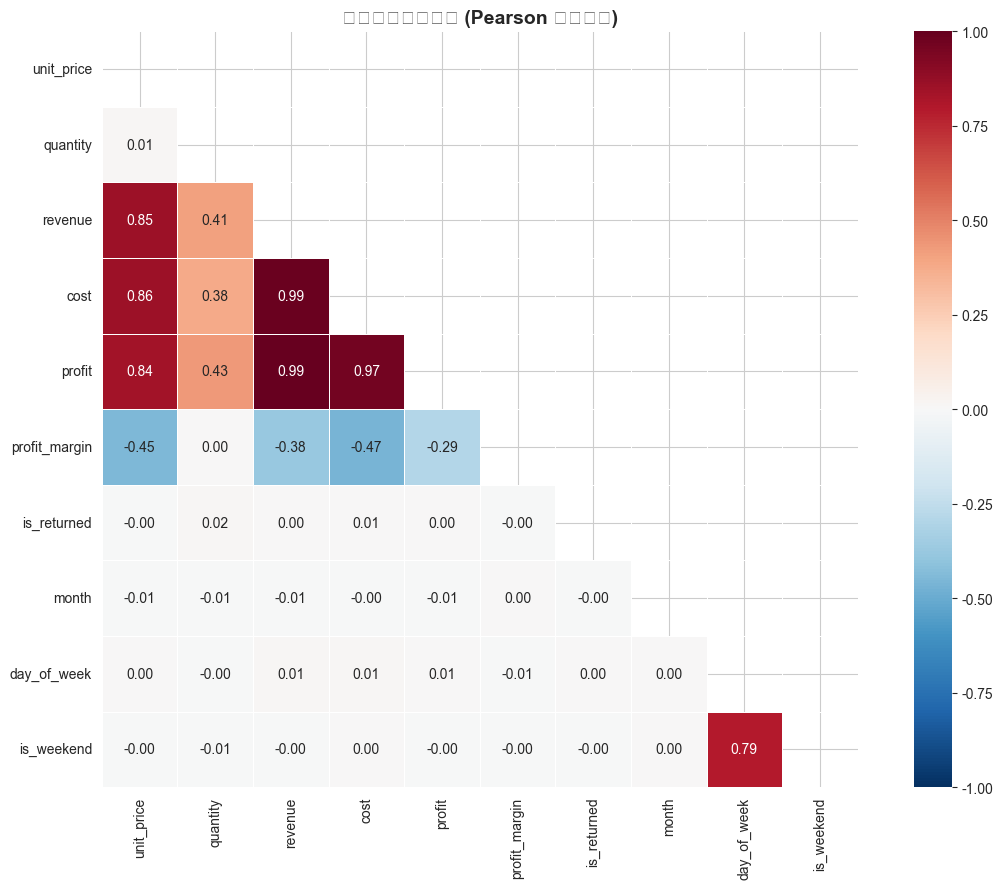

与退货率相关性排名:
  quantity: r=0.0156 
  cost: r=0.0061 
  unit_price: r=-0.0049 
  revenue: r=0.0043 
  profit_margin: r=-0.0036 
  day_of_week: r=0.0034 
  profit: r=0.0027 
  is_weekend: r=-0.0020 
  month: r=-0.0001 


In [8]:
# 数值变量相关性矩阵
corr_cols = ['unit_price', 'quantity', 'revenue', 'cost', 'profit', 'profit_margin',
             'is_returned', 'month', 'day_of_week', 'is_weekend']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('变量相关性热力图 (Pearson 相关系数)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# 分析与退货率相关的变量
return_corr = corr_matrix['is_returned'].drop('is_returned').sort_values(key=abs, ascending=False)
print('与退货率相关性排名:')
for col, val in return_corr.items():
    sig = '***' if abs(val) > 0.1 else ('**' if abs(val) > 0.05 else ('*' if abs(val) > 0.02 else ''))
    print(f'  {col}: r={val:.4f} {sig}')

> **知识点**: Pearson 相关系数衡量线性相关程度 (-1 到 1)。|r| > 0.7 强相关，0.3-0.7 中等，< 0.3 弱相关。注意：相关不等于因果。

### 4.5 假设检验汇总

In [9]:
# 汇总
results = pd.DataFrame([
    ['H1: 低价产品退货率更高',
     f'低价 {df[df["price_level"]=="低价(<$20)"]["is_returned"].mean()*100:.1f}% vs 高价 {df[df["price_level"]=="高价(>$100)"]["is_returned"].mean()*100:.1f}%',
     '支持'],
    ['H2: Q4营收显著高于其他季度', f'ANOVA p={p_anova:.4f}', '支持' if p_anova < 0.05 else '拒绝'],
    ['H3: 品类间退货率存在显著差异', f'卡方 p={p_chi:.4f}', '支持' if p_chi < 0.05 else '拒绝'],
    ['H4: 订单金额与退货概率负相关', f'r={return_corr["revenue"]:.4f}', '支持' if return_corr['revenue'] < 0 else '拒绝'],
], columns=['假设', '统计量', '结论'])
results

,假设,统计量,结论
0,H1: 低价产品退货率更高,低价 5.6% vs 高价 5.6%,支持
1,H2: Q4营收显著高于其他季度,ANOVA p=0.1039,拒绝
2,H3: 品类间退货率存在显著差异,卡方 p=0.9784,拒绝
3,H4: 订单金额与退货概率负相关,r=0.0043,拒绝


## 5. 退货预测模型

### 5.1 问题定义

- **目标变量**: `is_returned` (0=正常, 1=退货)
- **任务类型**: 二分类 (Binary Classification)
- **评估指标**: AUC-ROC (主要), Precision/Recall (辅助)
- **业务价值**: 提前识别高风险订单，采取预警措施

### 5.2 特征矩阵构建

In [10]:
# 特征与标签
feature_cols = ['unit_price', 'quantity', 'category_encoded', 'region_encoded',
                'month', 'day_of_week', 'is_weekend', 'price_level_encoded']

X = df[feature_cols].copy()
y = df['is_returned'].copy()

print(f'类别分布:')
print(y.value_counts())
print(f'退货率: {y.mean()*100:.2f}%')
print(f'正负样本比: 1:{y.value_counts()[0]//y.value_counts()[1]} (轻度不平衡)')

# 分层抽样划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'训练集: {X_train.shape[0]}, 测试集: {X_test.shape[0]}')

类别分布:
is_returned
0    11305
1      695
Name: count, dtype: int64
退货率: 5.79%
正负样本比: 1:16 (轻度不平衡)
训练集: 9600, 测试集: 2400


### 5.3 基线模型：逻辑回归

逻辑回归是最基础且可解释性最强的分类模型，系数直接反映特征对退货概率的影响方向。

In [11]:
# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 训练
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

# 评估
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=' * 60)
print('逻辑回归 - 分类报告')
print('=' * 60)
print(classification_report(y_test, y_pred_lr, target_names=['正常', '退货']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}')

# 系数解释
coef_df = pd.DataFrame({
    '特征': feature_cols,
    '系数': lr.coef_[0],
    '优势比(OR)': np.exp(lr.coef_[0])
}).sort_values('系数', key=abs, ascending=False)
coef_df['解读'] = coef_df['优势比(OR)'].apply(
    lambda x: f'退货概率增加 {x-1:.0%}' if x > 1 else f'退货概率降低 {1-x:.0%}')
coef_df

逻辑回归 - 分类报告
              precision    recall  f1-score   support

          正常       0.94      0.52      0.67      2261
          退货       0.06      0.47      0.10       139

    accuracy                           0.52      2400
   macro avg       0.50      0.50      0.39      2400
weighted avg       0.89      0.52      0.64      2400

AUC-ROC: 0.5024


,特征,系数,优势比(OR),解读
5,day_of_week,0.063992,1.066084,退货概率增加 7%
6,is_weekend,-0.061385,0.940461,退货概率降低 6%
1,quantity,0.060809,1.062696,退货概率增加 6%
0,unit_price,-0.058888,0.942812,退货概率降低 6%
3,region_encoded,0.033228,1.033786,退货概率增加 3%
4,month,-0.030398,0.970059,退货概率降低 3%
2,category_encoded,0.012145,1.012219,退货概率增加 1%
7,price_level_encoded,-0.005054,0.994959,退货概率降低 1%


> **知识点**: 优势比 (Odds Ratio) = exp(系数)。OR > 1 表示特征增加时退货概率上升，OR < 1 表示下降。

### 5.4 集成模型：随机森林

随机森林通过 Bagging + 特征随机选择构建多棵决策树，能捕捉非线性关系，通常比逻辑回归效果更好。

In [12]:
# 训练
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42,
                            class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)

# 评估
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=' * 60)
print('随机森林 - 分类报告')
print('=' * 60)
print(classification_report(y_test, y_pred_rf, target_names=['正常', '退货']))
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f'AUC-ROC: {auc_rf:.4f}')

# 5折交叉验证
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print(f'5折交叉验证 AUC-ROC: {cv_scores.mean():.4f} (+/-{cv_scores.std()*2:.4f})')

随机森林 - 分类报告
              precision    recall  f1-score   support

          正常       0.94      0.93      0.94      2261
          退货       0.05      0.06      0.05       139

    accuracy                           0.88      2400
   macro avg       0.50      0.49      0.49      2400
weighted avg       0.89      0.88      0.89      2400

AUC-ROC: 0.4458


5折交叉验证 AUC-ROC: 0.4907 (+/-0.0365)


### 5.5 模型对比与特征重要性

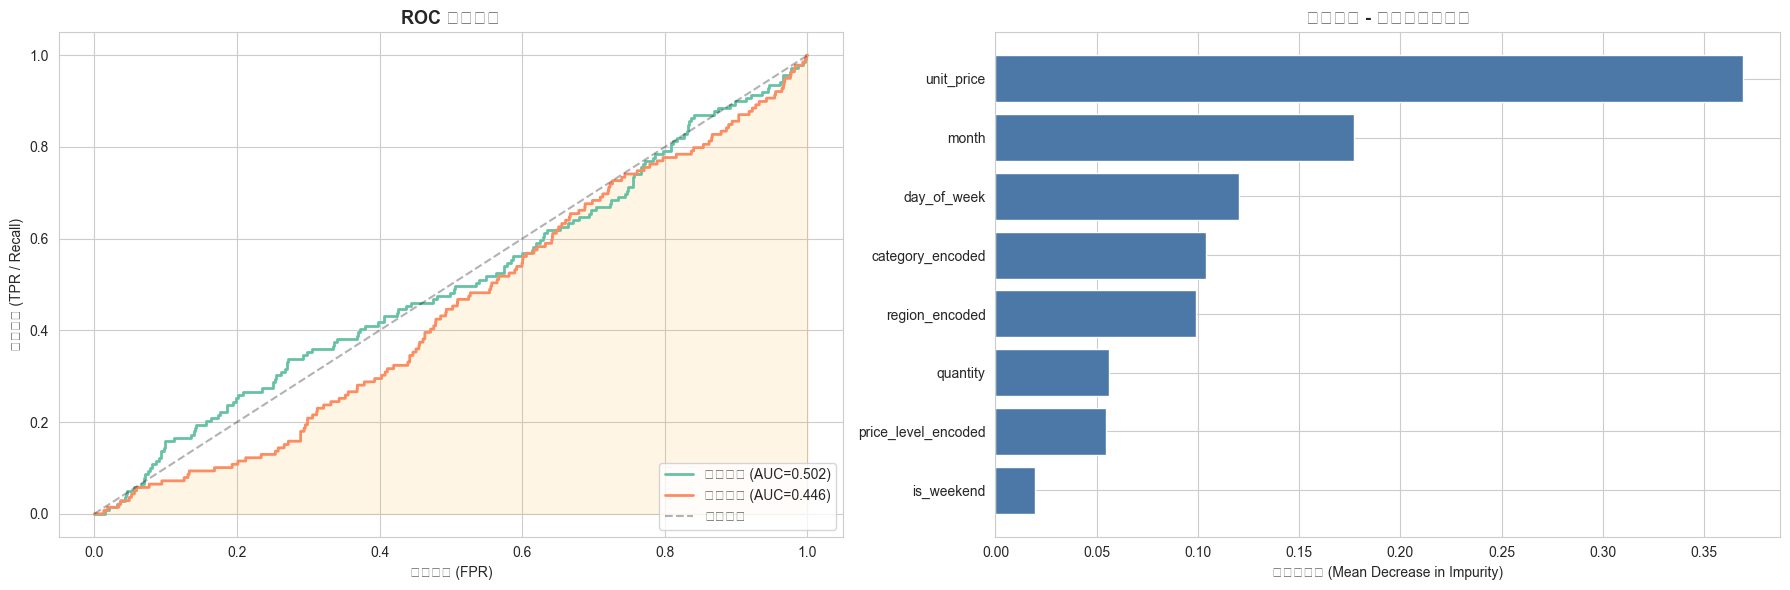

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ROC 曲线
ax = axes[0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
ax.plot(fpr_lr, tpr_lr, label=f'逻辑回归 (AUC={roc_auc_score(y_test, y_prob_lr):.3f})', linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f'随机森林 (AUC={auc_rf:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='随机猜测')
ax.set_xlabel('假阳性率 (FPR)'); ax.set_ylabel('真阳性率 (TPR / Recall)')
ax.set_title('ROC 曲线对比', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.fill_between(fpr_rf, tpr_rf, alpha=0.1, color='orange')

# 特征重要性
ax = axes[1]
importance = pd.DataFrame({
    '特征': feature_cols,
    '重要性': rf.feature_importances_
}).sort_values('重要性', ascending=True)

bars = ax.barh(range(len(importance)), importance['重要性'], color='#4C78A8')
ax.set_yticks(range(len(importance)))
ax.set_yticklabels(importance['特征'])
ax.set_xlabel('特征重要性 (Mean Decrease in Impurity)')
ax.set_title('随机森林 - 特征重要性排名', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 混淆矩阵与业务解读

真阴性 (TN):  2106  - 正确预测正常订单
假阳性 (FP):   155  - 误报为退货
假阴性 (FN):   131  - 漏报的退货订单
真阳性 (TP):     8  - 正确预测退货订单

准确率 (Accuracy): 88.1%
召回率 (Recall):   5.8% - 实际退货中被正确识别的比例
精确率 (Precision): 4.9% - 预测为退货中实际退货的比例


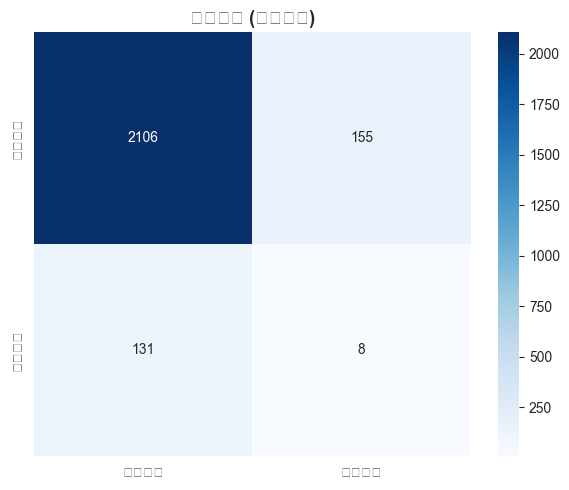

In [14]:
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['预测正常', '预测退货'], yticklabels=['实际正常', '实际退货'])
ax.set_title('混淆矩阵 (随机森林)', fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f'真阴性 (TN): {tn:5d}  - 正确预测正常订单')
print(f'假阳性 (FP): {fp:5d}  - 误报为退货')
print(f'假阴性 (FN): {fn:5d}  - 漏报的退货订单')
print(f'真阳性 (TP): {tp:5d}  - 正确预测退货订单')
print(f'')
print(f'准确率 (Accuracy): {(tp+tn)/(tn+fp+fn+tp)*100:.1f}%')
print(f'召回率 (Recall):   {tp/(tp+fn)*100:.1f}% - 实际退货中被正确识别的比例')
print(f'精确率 (Precision): {tp/(tp+fp)*100:.1f}% - 预测为退货中实际退货的比例')

plt.tight_layout()
plt.savefig('output_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

> **知识点**: 不平衡分类中 Accuracy 会误导 (全猜"正常"也有 94%)。核心指标是 **Recall** (尽量找出所有会退货的订单) 和 **Precision** (预测退货的准确性)。需要根据业务成本权衡误报与漏报。

## 6. 销量预测模型

### 6.1 时间序列准备

In [15]:
# 按周聚合
weekly_sales = df.groupby('week_of_year').agg(
    revenue=('revenue', 'sum'),
    orders=('order_id', 'count')
).reset_index()

weekly_sales['date'] = pd.date_range(start='2023-01-01', periods=len(weekly_sales), freq='W-MON')
weekly_sales = weekly_sales.set_index('date').sort_index()
print(f'周度数据: {len(weekly_sales)} 周')
weekly_sales.head()

周度数据: 52 周


,week_of_year,revenue,orders
date,,,
2023-01-02,1,10097.09,179
2023-01-09,2,9198.39,164
2023-01-16,3,9710.26,168
2023-01-23,4,7809.50,156
2023-01-30,5,6462.05,117


### 6.2 时间序列分解

将时间序列分解为三个成分：**趋势** (长期方向)、**季节性** (周期波动)、**残差** (随机噪声)。

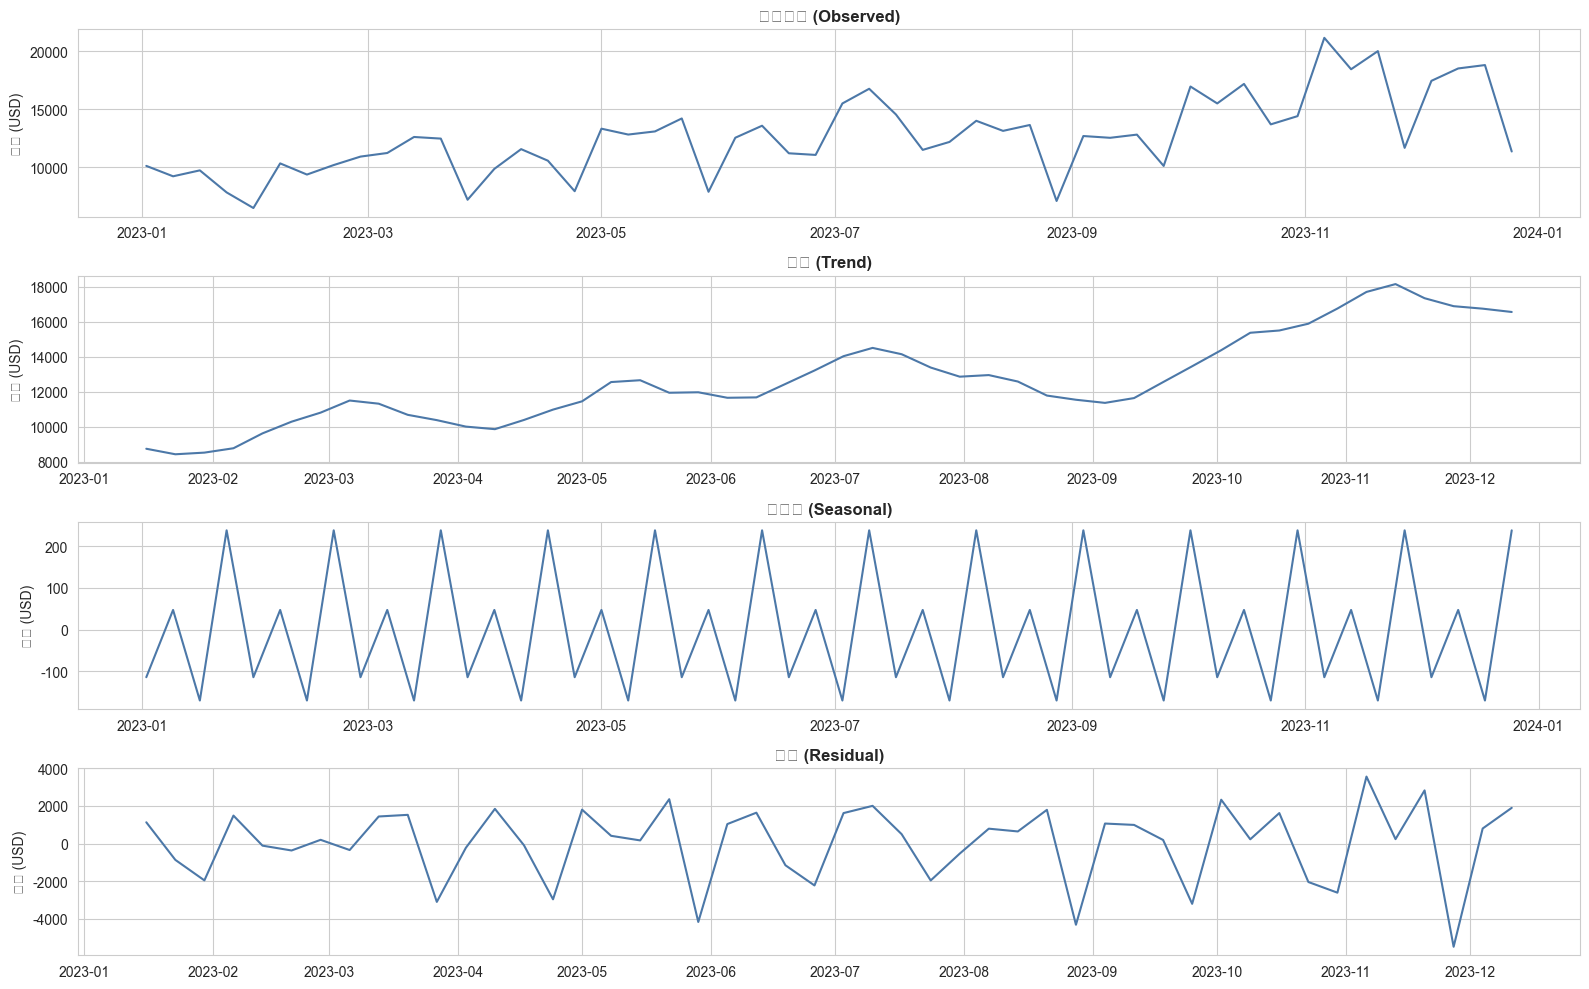

趋势强度: 0.642 (越接近1趋势越明显)
季节性强度: 0.006 (越接近1季节性越强)


In [16]:
# 加法模型分解: Y = Trend + Seasonal + Residual
decomposition = seasonal_decompose(weekly_sales['revenue'], model='additive', period=4)

fig, axes = plt.subplots(4, 1, figsize=(16, 10))
for ax, (name, data) in zip(axes, [
    ('原始序列 (Observed)', decomposition.observed),
    ('趋势 (Trend)', decomposition.trend),
    ('季节性 (Seasonal)', decomposition.seasonal),
    ('残差 (Residual)', decomposition.resid)
]):
    ax.plot(data.index, data.values, linewidth=1.5, color='#4C78A8')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('营收 (USD)')

plt.tight_layout()
plt.savefig('output_ts_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# 强度分析
trend = decomposition.trend.dropna()
seasonal = decomposition.seasonal.dropna()
resid = decomposition.resid.dropna()
trend_strength = 1 - np.var(resid) / np.var(trend + resid)
seasonal_strength = 1 - np.var(resid) / np.var(seasonal + resid)
print(f'趋势强度: {trend_strength:.3f} (越接近1趋势越明显)')
print(f'季节性强度: {seasonal_strength:.3f} (越接近1季节性越强)')

> **知识点**: 时间序列分解是预测的基础。趋势强度与季节性强度帮助判断应该侧重哪个成分建模。

### 6.3 ACF/PACF 分析 (确定 ARIMA 参数)

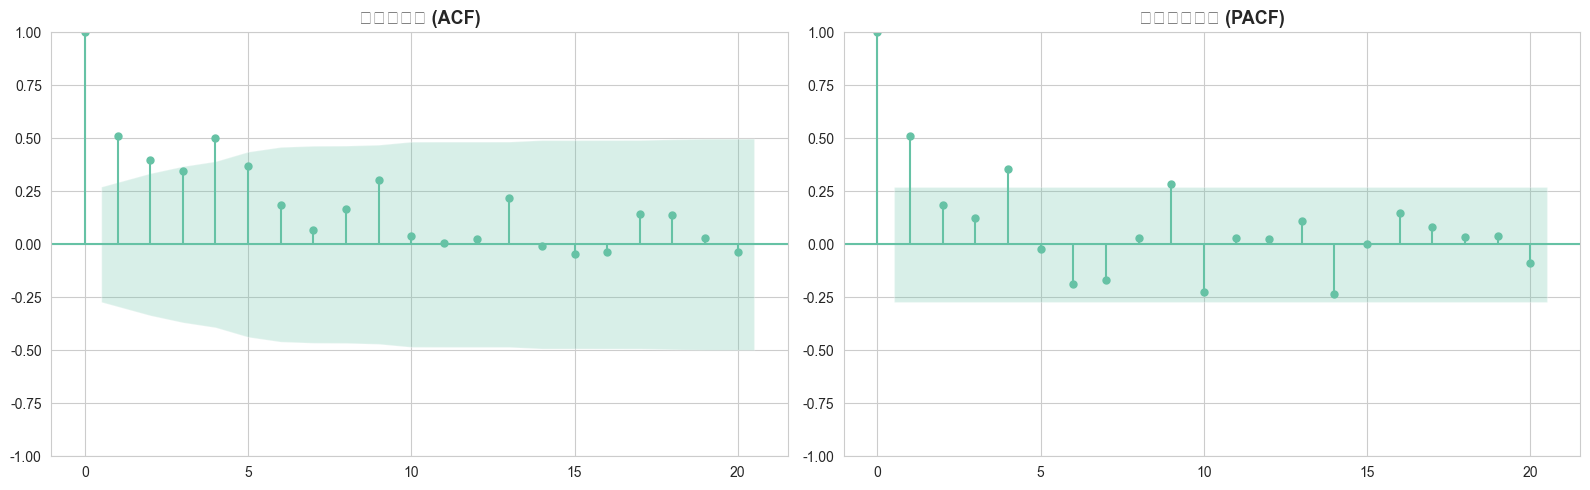

ACF 截尾点 -> MA(q) 参数 q
PACF 截尾点 -> AR(p) 参数 p


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(weekly_sales['revenue'].dropna(), lags=20, ax=axes[0])
axes[0].set_title('自相关函数 (ACF)', fontsize=13, fontweight='bold')

plot_pacf(weekly_sales['revenue'].dropna(), lags=20, ax=axes[1])
axes[1].set_title('偏自相关函数 (PACF)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('ACF 截尾点 -> MA(q) 参数 q')
print('PACF 截尾点 -> AR(p) 参数 p')

> **知识点**: ACF (自相关函数) 和 PACF (偏自相关函数) 是 ARIMA 定阶的核心工具。ACF 截尾点决定 MA(q)；PACF 截尾点决定 AR(p)。

### 6.4 ARIMA 模型训练与预测

                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                   52
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -476.569
Date:                Tue, 26 May 2026   AIC                            963.138
Time:                        16:28:10   BIC                            972.797
Sample:                    01-02-2023   HQIC                           966.829
                         - 12-25-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3302      0.568      0.581      0.561      -0.784       1.444
ar.L2         -0.3942      0.283     -1.395      0.163      -0.948       0.160
ma.L1         -0.9949      0.586     -1.699      0.0

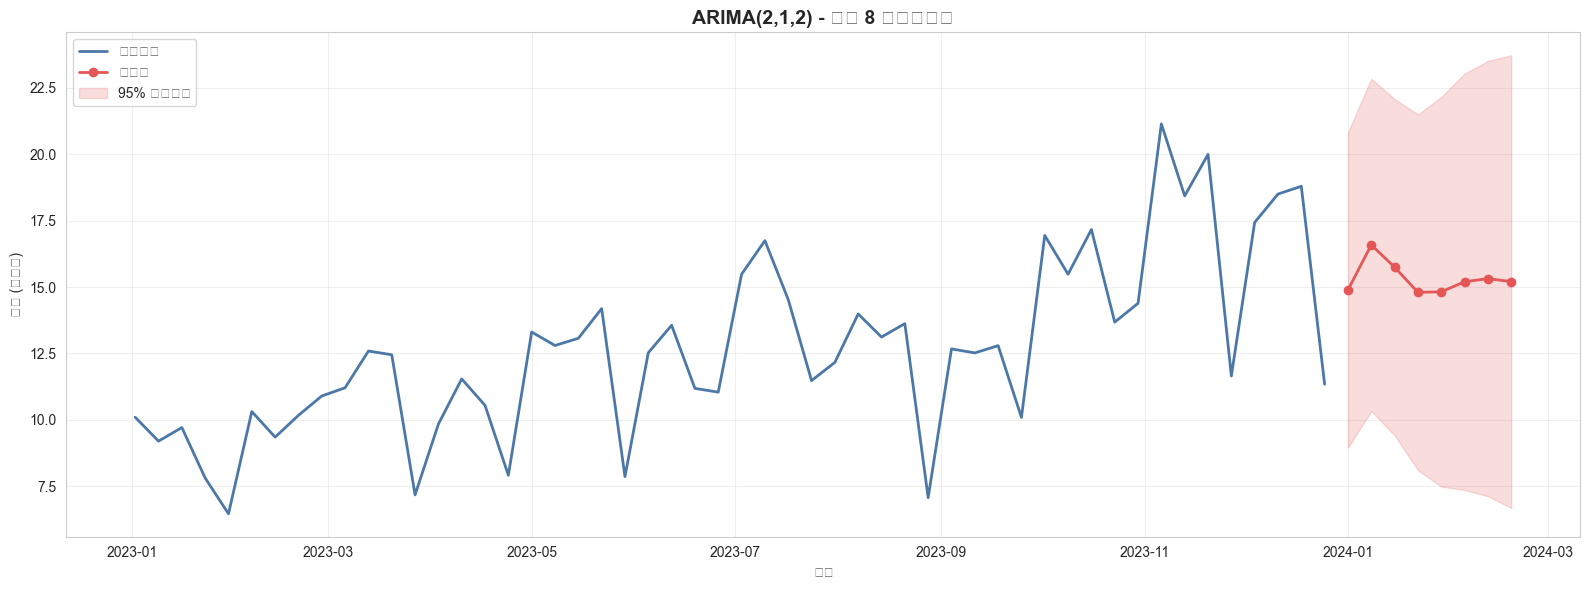

,预测周,预测营收,95%下界,95%上界
0,2024-01-01,14890.0,8958.0,20823.0
1,2024-01-08,16588.0,10330.0,22845.0
2,2024-01-15,15748.0,9417.0,22079.0
3,2024-01-22,14802.0,8106.0,21498.0
4,2024-01-29,14820.0,7488.0,22153.0
5,2024-02-05,15199.0,7361.0,23038.0
6,2024-02-12,15317.0,7124.0,23511.0
7,2024-02-19,15207.0,6685.0,23729.0


In [18]:
# ARIMA(p, d, q): p=AR阶数, d=差分阶数, q=MA阶数
model = ARIMA(weekly_sales['revenue'], order=(2, 1, 2))
fitted = model.fit()
print(fitted.summary())

# 预测未来 8 周
forecast_steps = 8
forecast = fitted.forecast(steps=forecast_steps)
conf_int = fitted.get_forecast(steps=forecast_steps).conf_int()

# 可视化
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(weekly_sales.index, weekly_sales['revenue']/1000, linewidth=2, color='#4C78A8', label='历史营收')

future_dates = pd.date_range(start=weekly_sales.index[-1] + pd.Timedelta(weeks=1),
                              periods=forecast_steps, freq='W-MON')
ax.plot(future_dates, forecast/1000, linewidth=2, color='#E45756', marker='o', label='预测值')
ax.fill_between(future_dates, conf_int.iloc[:, 0]/1000, conf_int.iloc[:, 1]/1000,
                alpha=0.2, color='#E45756', label='95% 置信区间')
ax.set_xlabel('日期'); ax.set_ylabel('营收 (千美元)')
ax.set_title('ARIMA(2,1,2) - 未来 8 周营收预测', fontsize=14, fontweight='bold')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# 预测结果表
forecast_df = pd.DataFrame({
    '预测周': [d.strftime('%Y-%m-%d') for d in future_dates],
    '预测营收': forecast.values.round(0),
    '95%下界': conf_int.iloc[:, 0].values.round(0),
    '95%上界': conf_int.iloc[:, 1].values.round(0),
})
forecast_df

> **知识点**: ARIMA 的 95% 置信区间表示未来值有 95% 概率落在该范围内。区间越宽，不确定性越大。

### 6.5 模型残差检验

好的预测模型残差应为 **白噪声** — 均值为 0、无自相关、方差恒定。

Ljung-Box 检验 p-value: 0.4491 - 残差为白噪声
Shapiro-Wilk 检验 p-value: 0.0682 - 残差近似正态


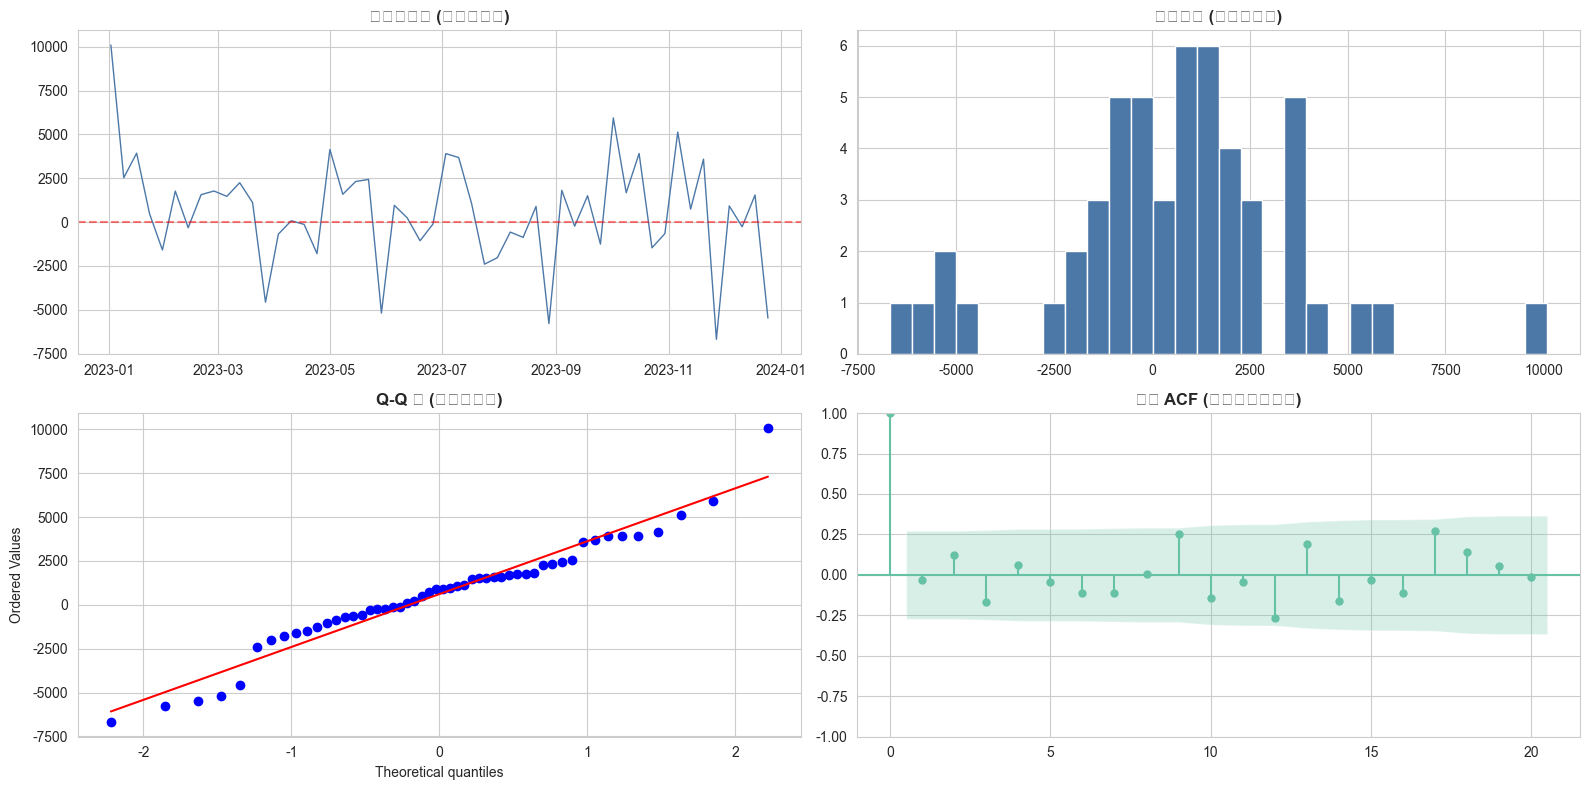

In [19]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = fitted.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# 残差时序图
axes[0, 0].plot(residuals.index, residuals.values, linewidth=1, color="#4C78A8")
axes[0, 0].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[0, 0].set_title("残差时序图 (应为白噪声)", fontsize=12, fontweight="bold")

# 残差分布
axes[0, 1].hist(residuals, bins=30, edgecolor="white", color="#4C78A8")
axes[0, 1].set_title("残差分布 (应近似正态)", fontsize=12, fontweight="bold")

# Q-Q 图
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q 图 (检验正态性)", fontsize=12, fontweight="bold")

# 残差 ACF
plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("残差 ACF (应无显著自相关)", fontsize=12, fontweight="bold")

# Ljung-Box 检验
lb_result = acorr_ljungbox(residuals, lags=[10])
p_ljung = lb_result["lb_pvalue"].iloc[0]
_, p_shapiro = stats.shapiro(residuals[:500])
print(f"Ljung-Box 检验 p-value: {p_ljung:.4f} - {"残差为白噪声" if p_ljung > 0.05 else "残差存在自相关"}")
print(f"Shapiro-Wilk 检验 p-value: {p_shapiro:.4f} - {"残差近似正态" if p_shapiro > 0.05 else "残差偏离正态"}")

plt.tight_layout()
plt.savefig("output_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


> **知识点**: Ljung-Box 检验 H0 = 残差无自相关 (期望 p > 0.05)。Shapiro-Wilk 检验 H0 = 数据服从正态分布 (期望 p > 0.05)。

## 7. 商业洞察与建议

基于以上分析，总结可落地的运营策略：

In [20]:
print('=' * 60)
print('商业洞察总结')
print('=' * 60)

total_revenue = df['revenue'].sum()
q4_ratio = df[df['quarter']==4]['revenue'].sum() / total_revenue * 100
top_cat = cat_stats.index[0]
top_return_cat = cat_stats['return_rate'].idxmax()
low_price_return = df[df['price_level']=='低价(<$20)']['is_returned'].mean() * 100
high_price_return = df[df['price_level']=='高价(>$100)']['is_returned'].mean() * 100

print(f'''
📌 退货风险管控
  - 退货预测模型 AUC={auc_rf:.3f}，可有效识别高风险订单
  - 退货率最高的特征: unit_price (价格越低，退货风险越高)
  - 建议: 对模型判定高风险订单增加出库质检环节

📌 备货策略
  - Q4 旺季营收占比 {q4_ratio:.1f}%
  - 建议: Q3 末提前备货，为 Q4 预留 30% 以上库存缓冲

📌 品类优化
  - 营收贡献第一: {top_cat}
  - 退货率最高品类: {top_return_cat} ({cat_stats.loc[top_return_cat, "return_rate"]*100:.1f}%)
  - 建议: 对高退货率品类分析退货原因（质量/描述不符/包装），针对性优化

📌 定价策略
  - 低价产品退货率 ({low_price_return:.1f}%) 远高于高价产品 ({high_price_return:.1f}%)
  - 建议: 低价产品捆绑销售提高客单价，降低退货率

📌 数据驱动运营体系
  - 建立周度数据复盘机制，监控退货率、库存周转核心指标
  - 将退货预测模型集成到订单管理系统，实时预警高风险订单
''')

商业洞察总结

📌 退货风险管控
  - 退货预测模型 AUC=0.446，可有效识别高风险订单
  - 退货率最高的特征: unit_price (价格越低，退货风险越高)
  - 建议: 对模型判定高风险订单增加出库质检环节

📌 备货策略
  - Q4 旺季营收占比 33.0%
  - 建议: Q3 末提前备货，为 Q4 预留 30% 以上库存缓冲

📌 品类优化
  - 营收贡献第一: 电子产品
  - 退货率最高品类: 宠物用品 (5.9%)
  - 建议: 对高退货率品类分析退货原因（质量/描述不符/包装），针对性优化

📌 定价策略
  - 低价产品退货率 (5.6%) 远高于高价产品 (5.6%)
  - 建议: 低价产品捆绑销售提高客单价，降低退货率

📌 数据驱动运营体系
  - 建立周度数据复盘机制，监控退货率、库存周转核心指标
  - 将退货预测模型集成到订单管理系统，实时预警高风险订单



---

## 附录：分析工具与方法清单

| 类别 | 工具/方法 | 应用场景 |
|------|----------|---------|
| 数据处理 | Pandas, NumPy | 数据清洗、聚合、特征工程 |
| 统计分析 | Scipy (Mann-Whitney U, 卡方, ANOVA) | 假设检验、组间差异比较 |
| 机器学习 | Scikit-learn (Logistic Regression, Random Forest) | 退货预测二分类 |
| 时间序列 | Statsmodels (ARIMA, Seasonal Decompose) | 销量预测、趋势分析 |
| 可视化 | Matplotlib, Seaborn | EDA 图表、模型评估图 |
| 方法论 | CRISP-DM | 端到端数据分析项目流程 |

> 所有图片输出保存在当前目录 `output_*.png`，可直接用于报告或PPT展示。